In [1]:
import sys
sys.path.append('../code/sfdi/')

import importlib
import sfdi_fitter
import sfdi_fitter.data as sd
from sfdi_fitter.pipeline import SFDIPipeline
from sfdi_fitter import preprocess
import sfdi_fitter.demodulation as dmd
import sfdi_fitter.reflectance as sr
import sfdi_fitter.transformers as tr
# importlib.reload(dmd)
importlib.reload(sr)
# importlib.reload(preprocess)
# importlib.reload(sd)

%matplotlib inline
import matplotlib.pyplot as plt

import sys
sys.path.append('../code/')
import IB_external_sfdi_fit as exfit
importlib.reload(exfit)
import os

import glob
import tqdm
import numpy as np
import lab_tools.plot_utils as pu
pu.load_figure_style()

import matplotlib.pyplot as plt
import pandas as pd

Folders successfully configured: ['/4tb_drive/ipython/notebooks/Ilia/Glucosa/code/', '/4tb_drive/ipython/notebooks/Ilia/Glucosa/code/sfdi/']


## 07.04.2026: Occlusion test

### Попробуем обработать измерения ppg

In [2]:
def read_single_wv(path, color):
    
    paths = glob.glob(os.path.join(path, f'{color}/*'))
    lst = []
    for path_ in paths:
        
        img = plt.imread(path_)
        lst.append(img)
        
    return np.array(lst)

def get_phantom_number(path):

    basename = os.path.basename(path)
    return float((basename).split('_')[2].split('=')[1])

def get_number_and_time_from_basename(basename):
    
    number = float(basename.split('_')[0])
    time_lst = basename.split('_')[1].split('-')
    time = int(time_lst[0])*60*60 + int(time_lst[1])*60 + int(time_lst[2])
    
    return number, time

fx = 0.13158

spat_freqs = [fx*2*3.14]
spat_freqs

[0.8263224]

In [3]:
ilia_path1 = glob.glob(f'/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/*exp=1*') + ['/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/calibration/21-23-44_phantom=9_mua=0.5_mus=25_exp=1_exp']
ilia_path2 = glob.glob(f'/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/*exp=2*') + ['/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/calibration/21-24-17_phantom=9_mua=0.5_mus=25_exp=2_exp']
ilia_path3 = glob.glob(f'/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/*exp=3*') + ['/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/calibration/21-25-38_phantom=9_mua=0.5_mus=25_exp=3_exp']

ilia_path1.sort(key=get_phantom_number)
ilia_path2.sort(key=get_phantom_number)
ilia_path3.sort(key=get_phantom_number)

path2_dict = {get_phantom_number(p): p for p in ilia_path2}
path3_dict = {get_phantom_number(p): p for p in ilia_path3}

/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/calibration/21-23-44_phantom=9_mua=0.5_mus=25_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/calibration/21-24-17_phantom=9_mua=0.5_mus=25_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/calibration/21-25-38_phantom=9_mua=0.5_mus=25_exp=3_exp


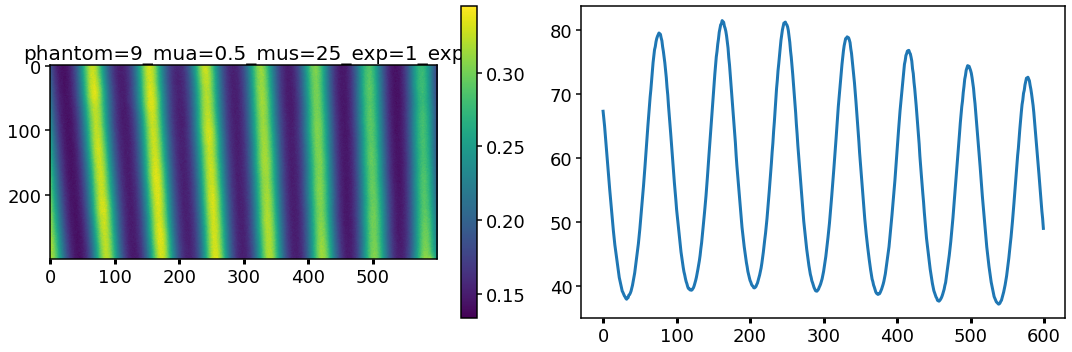

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/20-58-53_patient=Ilia_number=1_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/20-59-09_patient=Ilia_number=1_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/20-59-35_patient=Ilia_number=1_exp=3_exp


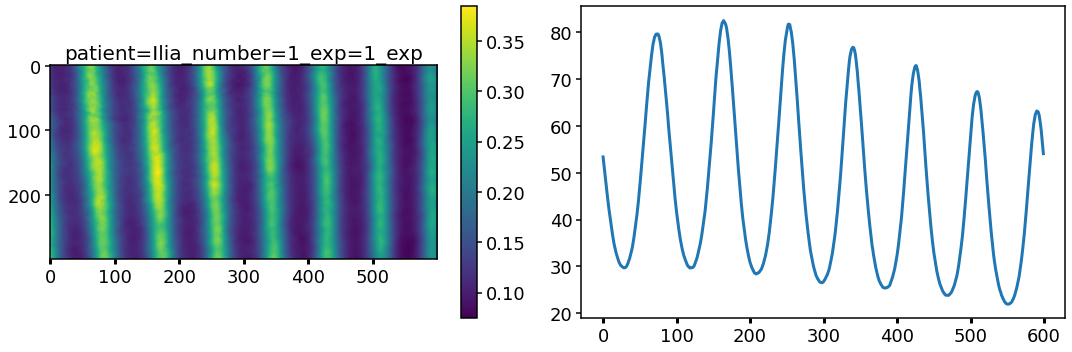

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-00-25_patient=Ilia_number=2_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-00-44_patient=Ilia_number=2_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-01-12_patient=Ilia_number=2_exp=3_exp


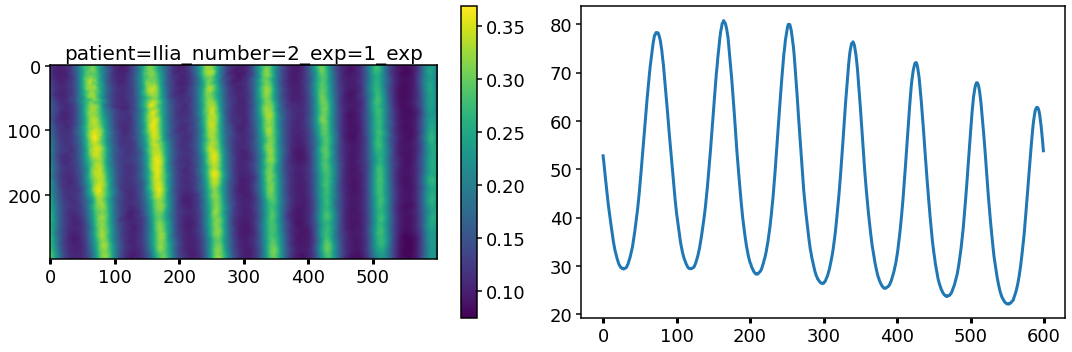

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-01-53_patient=Ilia_number=3_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-02-14_patient=Ilia_number=3_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-02-40_patient=Ilia_number=3_exp=3_exp


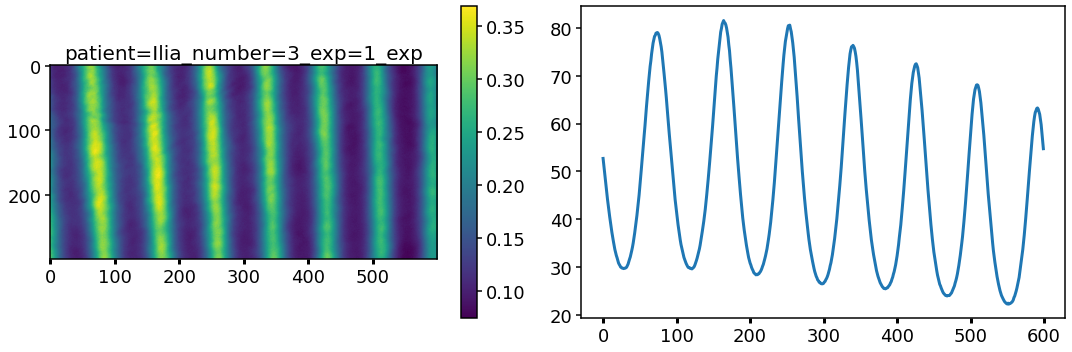

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-03-26_patient=Ilia_number=4_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-03-38_patient=Ilia_number=4_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-03-57_patient=Ilia_number=4_exp=3_exp


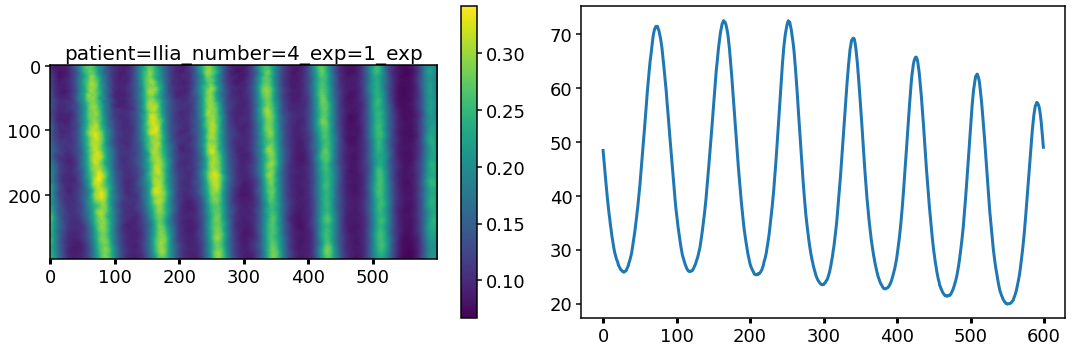

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-04-36_patient=Ilia_number=5_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-04-51_patient=Ilia_number=5_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-05-11_patient=Ilia_number=5_exp=3_exp


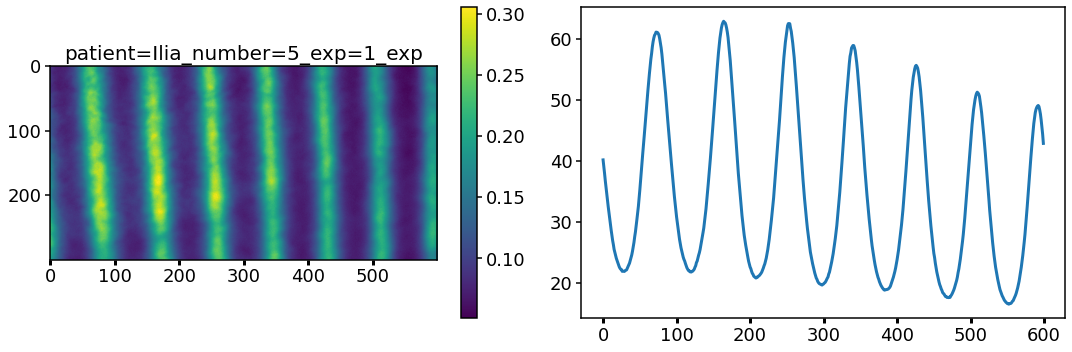

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-05-48_patient=Ilia_number=6_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-06-03_patient=Ilia_number=6_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-06-26_patient=Ilia_number=6_exp=3_exp


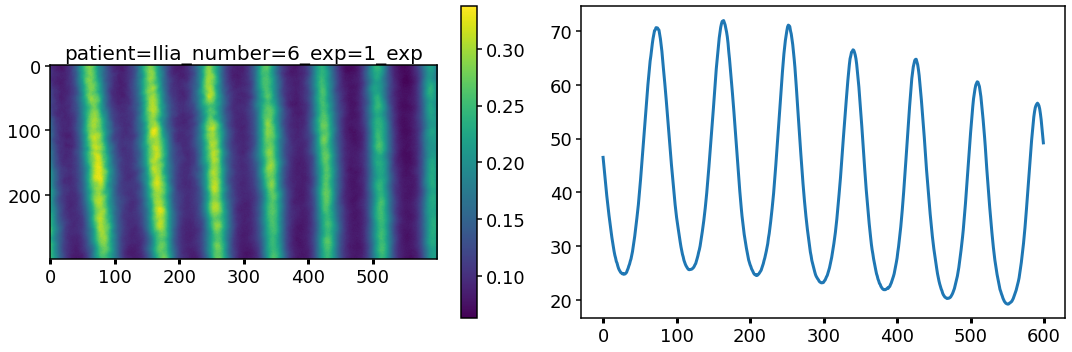

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-07-02_patient=Ilia_number=7_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-07-18_patient=Ilia_number=7_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-07-42_patient=Ilia_number=7_exp=3_exp


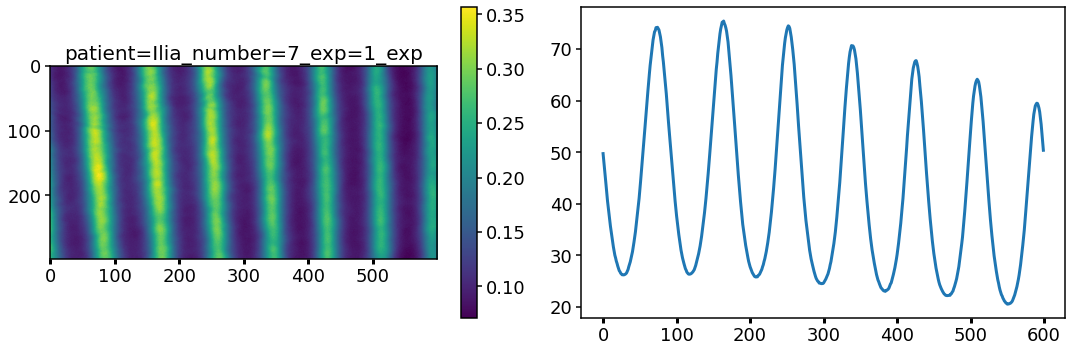

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-08-25_patient=Ilia_number=8_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-08-41_patient=Ilia_number=8_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-09-04_patient=Ilia_number=8_exp=3_exp


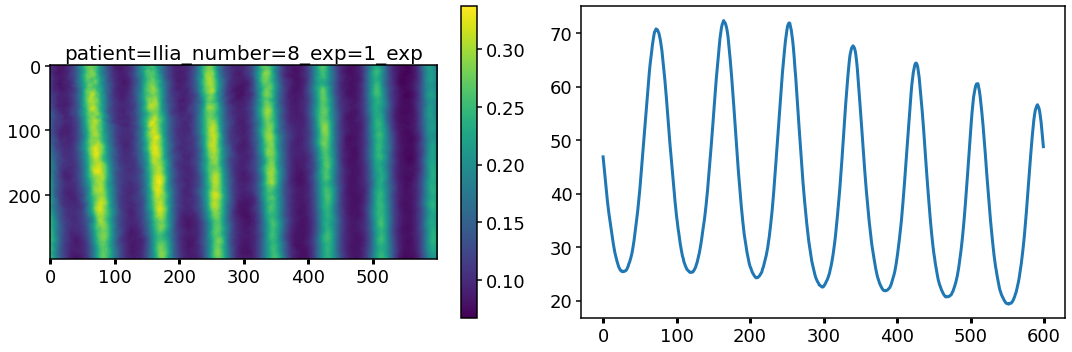

(4, 1, 1, 300, 600)
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-09-48_patient=Ilia_number=9_exp=1_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-10-05_patient=Ilia_number=9_exp=2_exp
/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/Ilia_occlusion/21-11-07_patient=Ilia_number=9_exp=3_exp


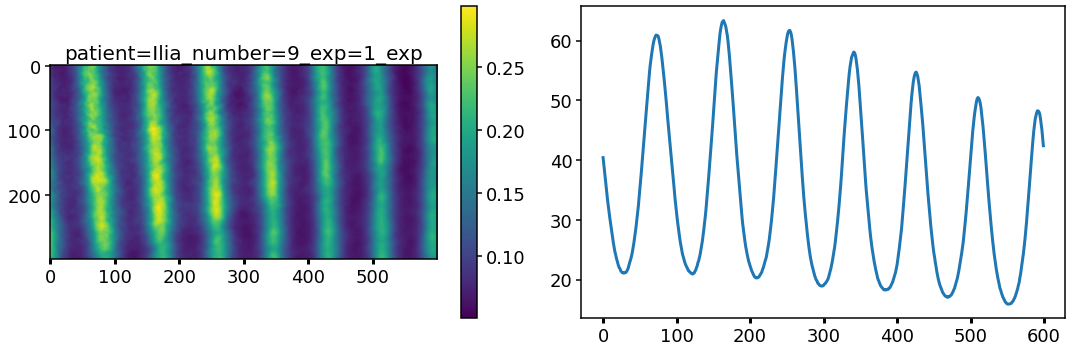

(4, 1, 1, 300, 600)


In [5]:
raw_dct = {}
mask = (slice(300, 900), slice(1000, 1300))

for path1 in ilia_path1:
    
    phantom_num = get_phantom_number(path1)
    path2 = path2_dict.get(phantom_num)
    path3 = path3_dict.get(phantom_num)
    
    print(path1)
    print(path2)
    print(path3)
    
    stack_red = read_single_wv(path1, color='RED')
    stack_green = read_single_wv(path2, color='GREEN')
    stack_810 = read_single_wv(path2, color='810')
    stack_940 = read_single_wv(path3, color='940')
    
    name = os.path.basename(path1)[9:]
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.title(name)
    plt.imshow((stack_green[0][mask]/255).T)
    plt.colorbar()
    
    plt.subplot(1, 2, 2)
    plt.plot(stack_green[0][mask].mean(axis=1))
    
    plt.tight_layout()
    plt.show()
    
    stack = np.array([(stack_green[0][mask]/255).T, (stack_red[0][mask]/255).T, 
             (stack_810[0][mask]/255).T, (stack_940[0][mask]/255).T])
    
    stack = stack[:, np.newaxis, np.newaxis, :, :]
    
    print(stack.shape)
    stack = sd.SFDIStack(stack, axis_names=[sd.StackAxis.WAVELENGTH,
                                            sd.StackAxis.FREQUENCY,
                                                     sd.StackAxis.PHASE,
                                                     sd.StackAxis.X,
                                                     sd.StackAxis.Y],
                         spatial_frequencies=spat_freqs,
                        wavelengths = ['525', '635', '810', '950'])
    
    raw_dct[name] = stack

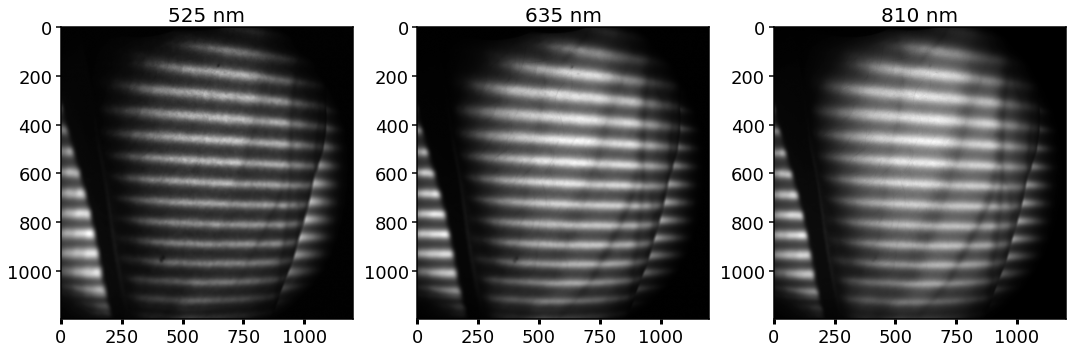

In [180]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(stack_green[0][:, 500:1700], cmap='gray')
plt.title('525 nm')

plt.subplot(1, 3, 2)
plt.imshow(stack_red[0][:, 500:1700], cmap='gray')
plt.title('635 nm')

plt.subplot(1, 3, 3)
plt.imshow(stack_810[0][:, 500:1700], cmap='gray')
plt.title('810 nm')

plt.tight_layout()
# plt.subplot(1, 4, 4)
# plt.imshow(stack_940[0][:, :1700], cmap='gray')

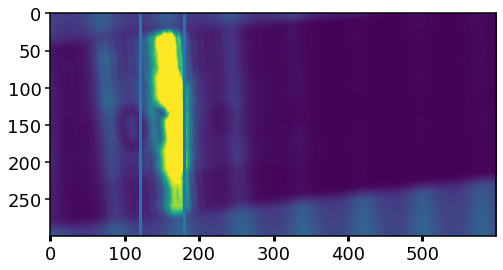

In [93]:
path_ruller = '/2tb_drive/data/Glucose/data_fast_sfdi/07_04_2026/ruller/21-26-22_ruller_exp=1_exp/RED/1_21-26-23_880895.tif'

img = plt.imread(path_ruller)
plt.imshow(img[mask].T)

plt.axvline(120)
plt.axvline(180)
pix_in_mm = 12
pix_in_period = 92

92

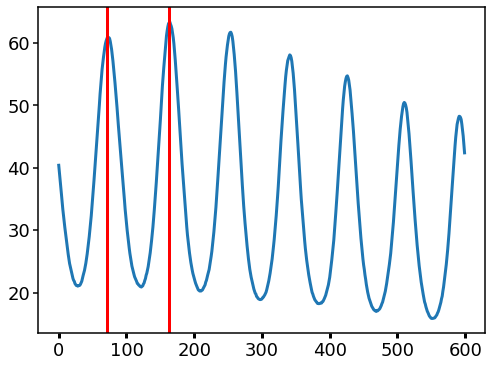

In [74]:
plt.plot(stack_green[0][mask].mean(axis=1))

plt.axvline(71, c='r')
plt.axvline(163, c='r')

163-71

## Задаем Референсный фантом

In [65]:
ref_mua_525 = 0.0458847464092525
ref_mus_525 = 2.773955679472813

ref_mua_635 = 0.04507811961917679
ref_mus_635 =1.8131597898818184

ref_mua_810 = 0.017384992768173606
ref_mus_810 = 1.0523143270538482

ref_mua_950 = 0.00806414868423144
ref_mus_950 = 0.7368520707297794

ref_name = 'phantom=9_mua=0.5_mus=25_exp=1_exp'
ref_raw_stack = raw_dct[ref_name]

In [97]:
#### Определяем ssmd pipeline
preprocessing_pipeline_ssmd = SFDIPipeline(
[
    ('demodulator',dmd.CosConvolveDemodulator(convolution_period=76)),
    ('binner', tr.MeanSmoother(kernel_size=9)), 
    ('squeeze', tr.StackSqueezer())
]
)

ref_stack_ssmd = preprocessing_pipeline_ssmd.process(ref_raw_stack)
mcml_model_ssmd = sfdi_fitter.fitter.MCML_model(spatial_frequencies=[0]+ spat_freqs)

reflectance_pipeline_ssmd = SFDIPipeline([
    ('preprocessing_pipeline',preprocessing_pipeline_ssmd),
    ('reflectance_calculator',sr.ReflectanceCalculator(reference_stack=ref_stack_ssmd,
                                                       reflectance_model=mcml_model_ssmd,
                                                       ref_mua = {'525': ref_mua_525,
                                                                  '635':ref_mua_635,
                                                                  '810':ref_mua_810,
                                                                  '950':ref_mua_950
                                                                 },
                                                       ref_mus_prime= {'525': ref_mus_525,
                                                                  '635': ref_mus_635,
                                                                  '810': ref_mus_810,
                                                                  '950': ref_mus_950}))
])


fit_pipeline_ssmd = SFDIPipeline([
    ('preprocessing_pipeline',preprocessing_pipeline_ssmd),
    ('reflectance_calculator',sr.ReflectanceCalculator(reference_stack=ref_stack_ssmd,
                                                       reflectance_model=mcml_model_ssmd,
                                                       ref_mua = {'525': ref_mua_525,
                                                                  '635':ref_mua_635,
                                                                  '810':ref_mua_810,
                                                                  '950':ref_mua_950
                                                                 },
                                                       ref_mus_prime= {'525': ref_mus_525,
                                                                  '635': ref_mus_635,
                                                                  '810': ref_mus_810,
                                                                  '950': ref_mus_950})),
    ('clipper',tr.Clipper(clip_min=0,clip_max=10)),
    ('fitter',sr.ReflectanceFitter(reflectance_model=mcml_model_ssmd))
])

In [98]:
mac_dct_ssmd = {}

for key, stack in tqdm.tqdm(raw_dct.items()):
    
    mac_dct_ssmd[key] = reflectance_pipeline_ssmd.process(stack)

100%|██████████| 10/10 [00:13<00:00,  1.32s/it]


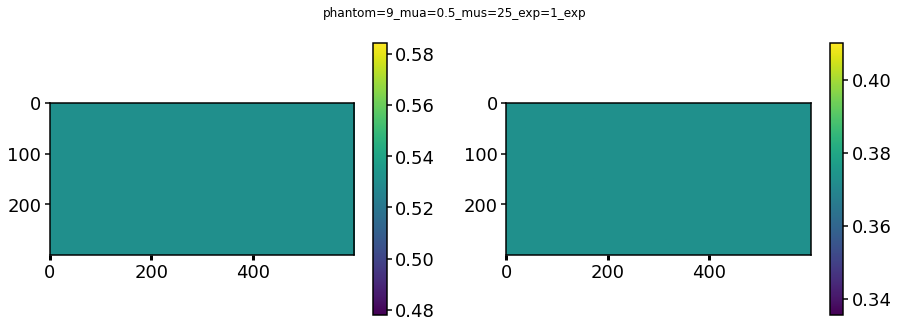

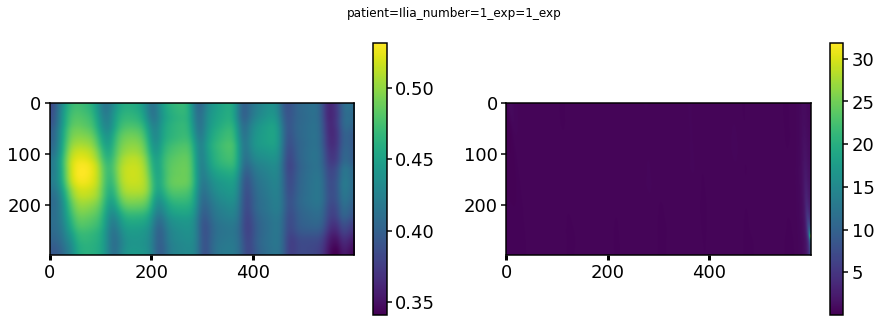

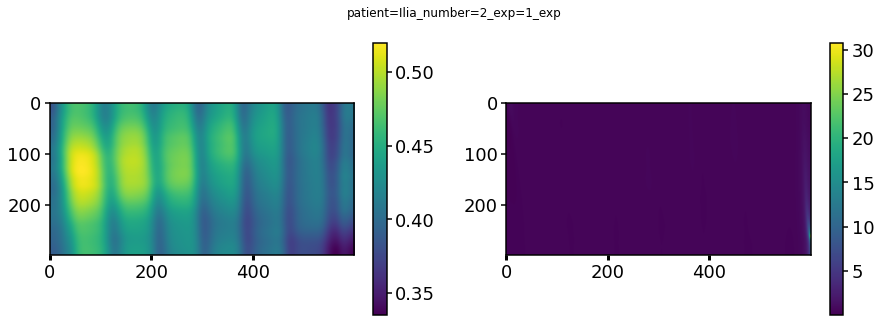

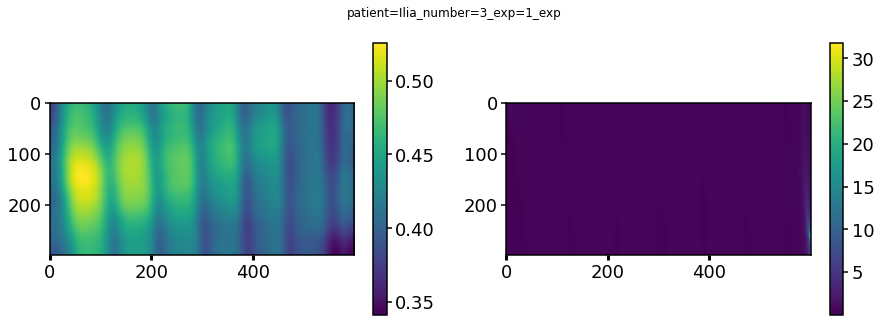

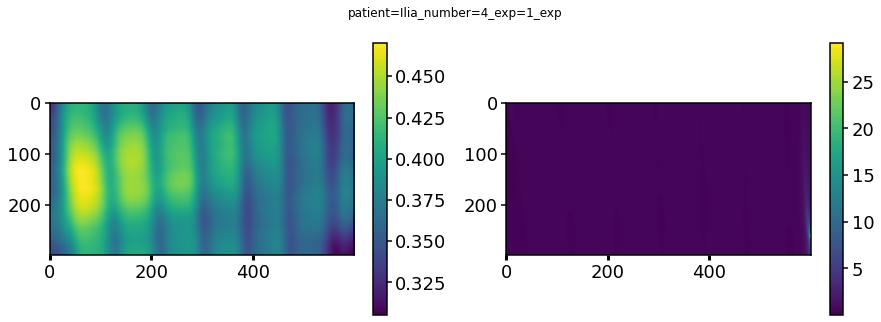

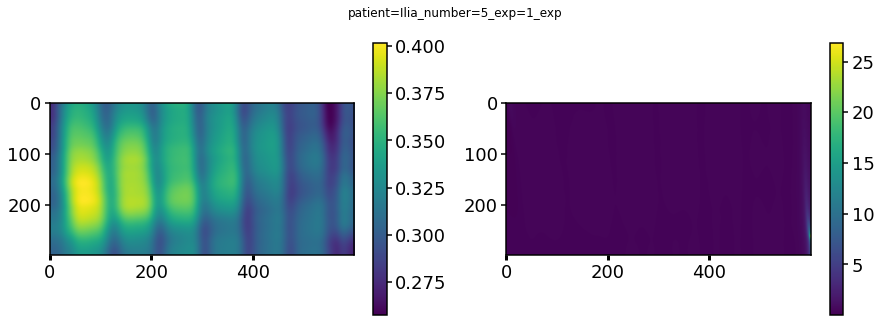

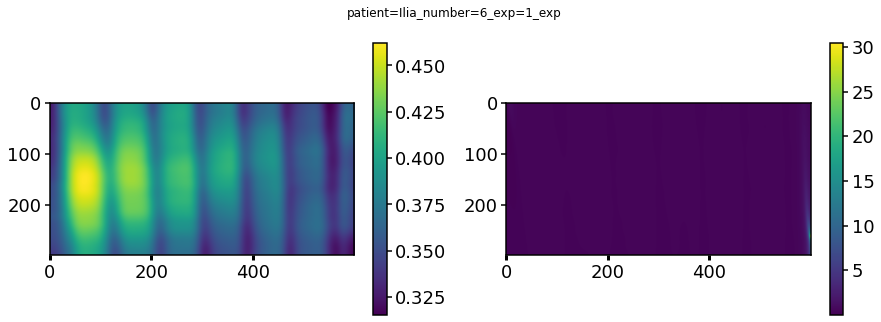

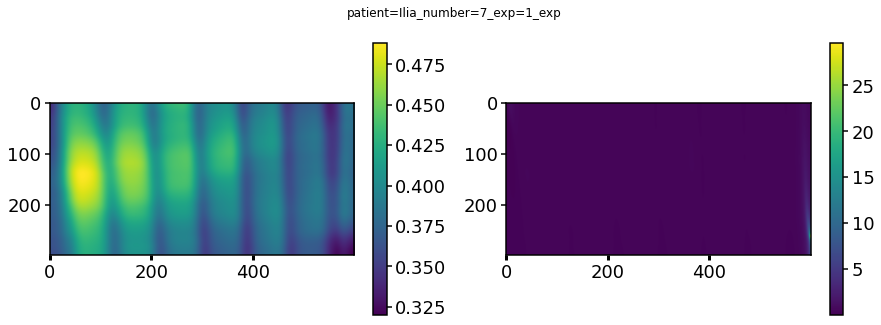

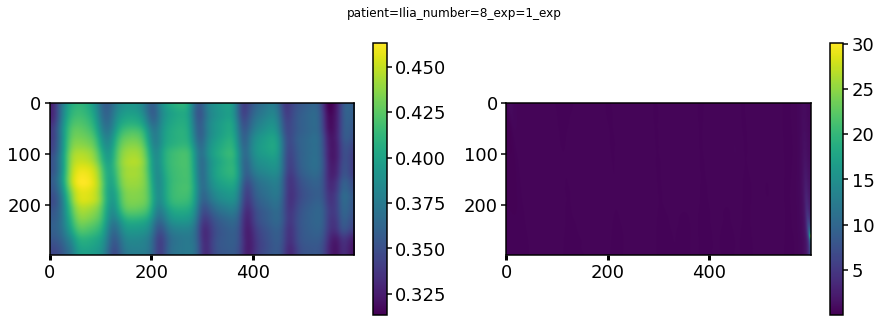

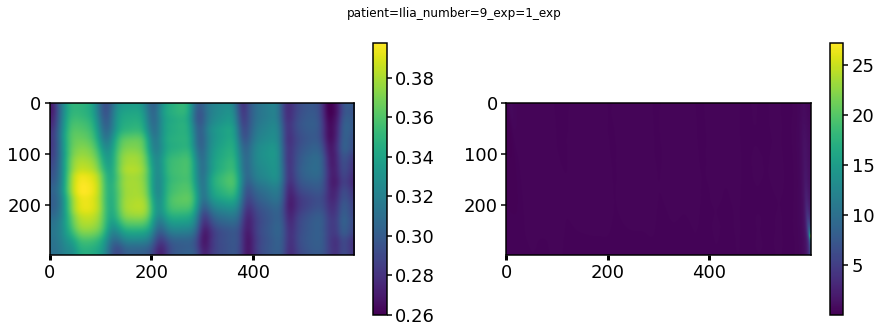

In [99]:
lst_name = []
lst_mac = []
lst_mdc = []
for name, stack in mac_dct_ssmd.items():
    
    plt.figure(figsize=(15, 5))
    plt.suptitle(name)
    
    plt.subplot(1, 2, 1)
    plt.imshow(stack.data[0][0])
    plt.colorbar()
    
    plt.subplot(1, 2, 2)
    plt.imshow(stack.data[0][1])
    plt.colorbar()
    
    plt.show()
    
    lst_name.append(name)
    lst_mac.append(stack.data[0][1])
    lst_mdc.append(stack.data[0][0])

In [100]:
data_rac= pd.DataFrame({'name':lst_name, 'mac':lst_mac, 'mdc':lst_mdc})
data_rac.sort_values(by='name', inplace=True)

/tmp/ipykernel_3434197/756906244.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter((row['mac']).reshape(-1), (row['mdc']).reshape(-1), label=row['name'], c = colors[i], s=2)


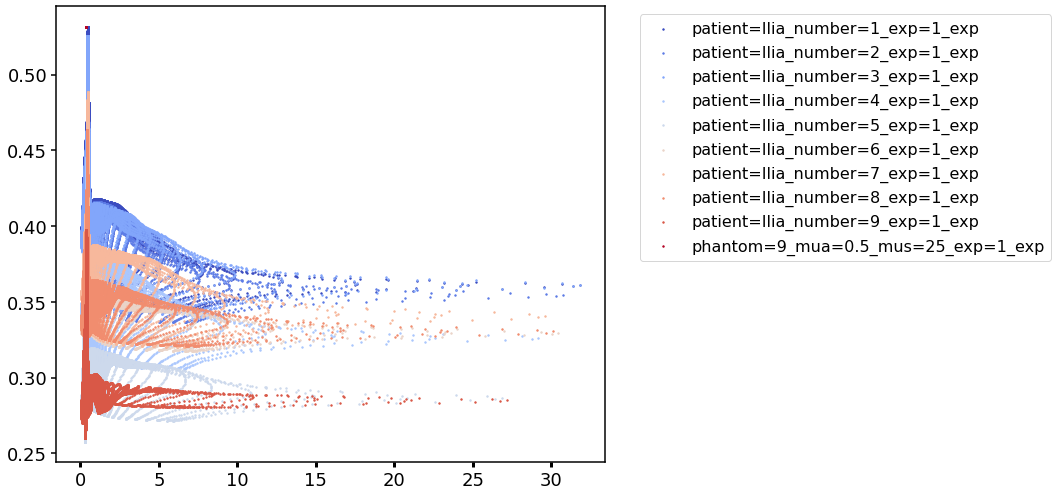

In [101]:
plt.figure(figsize=(15, 7))
colors = pu.get_colors(len(data_rac))

for i, (_, row) in enumerate(data_rac.iterrows()):
    
    plt.scatter((row['mac']).reshape(-1), (row['mdc']).reshape(-1), label=row['name'], c = colors[i], s=2)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 

In [102]:
map_dct_ssmd = {}

for key, stack in tqdm.tqdm(raw_dct.items()):
    
    map_dct_ssmd[key] = fit_pipeline_ssmd.process(stack)

100%|██████████| 10/10 [00:33<00:00,  3.35s/it]


In [103]:
def p25(vals):
    return np.percentile(vals,25)
    
def p75(vals):
    return np.percentile(vals,75)
    
def nanmedian(vals):
    _na_mask = np.isnan(vals)
    return np.median(vals[~_na_mask])

def melt_columns(multiindex_cols):
    melted_cols = []
    for col in multiindex_cols:
        if isinstance(col,tuple):
            if len(col) > 1:
                melted_cols.append('__'.join(col))
            else:
                melted_cols.append(col[0]) #col
        else:
            melted_cols.append(col)
    return melted_cols

def trunc_mean(x,qlo=10,qhi=90):
    _mask = ~np.isnan(x)
    _x = x[_mask]
    lo,hi = np.percentile(x,[qlo,qhi])
    
    p_mask = (_x > lo)&(_x < hi)
    return np.mean(_x[p_mask])

def dict_to_df(map_dct_ssmd, wv=True):
    lst = []
    
    for name, result in map_dct_ssmd.items():
        
        dct = {}
        dct['name'] = name
        
        if wv ==True:
            
            _stack_iterator = result.iterate_over_axes(sd.StackAxis.WAVELENGTH, sd.StackAxis.RESULTS)

            for (wv_id, par_id), stack_slice in _stack_iterator:

                wv_ = result.wavelengths[wv_id]
                par_type = result.parameter_names[par_id]

                dct[f'{par_type}_{wv_}'] = stack_slice
                
        else:
            
            _stack_iterator = result.iterate_over_axes(sd.StackAxis.RESULTS)

            for (par_id, ), stack_slice in _stack_iterator:

                par_type = result.parameter_names[par_id]

                dct[f'{par_type}_'] = stack_slice
            
        lst.append(dct)

    return pd.DataFrame(lst)

In [110]:
data_ssmd = dict_to_df(map_dct_ssmd=map_dct_ssmd, wv=True)

In [112]:
def aggregate_row(row):
    """Агрегирует значения в каждой колонке строки"""
    result = {'name': row['name']}
    
    for col in row.index:
        if col != 'name':
            values = row[col]
            result[f'{col}_median'] = nanmedian(values)
            result[f'{col}_p25'] = p25(values)
            result[f'{col}_p75'] = p75(values)
            result[f'{col}_trunc_mean'] = trunc_mean(values)
    
    return pd.Series(result)


result_df_ssmd = data_ssmd.apply(aggregate_row, axis=1)
result_df_ssmd['number'] = result_df_ssmd['name'].apply(lambda x: float(x.split('_')[1].split('=')[1]))

/home/gleb/venvs/jupyterhub_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gleb/venvs/jupyterhub_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gleb/venvs/jupyterhub_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gleb/venvs/jupyterhub_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [118]:
result_df_ssmd['patient'] = result_df_ssmd['name'].apply(lambda x: x.split('_')[0].split('=')[1])
df = result_df_ssmd[result_df_ssmd['patient'] == 'Ilia']

In [120]:
import sklearn.metrics 

def calculate_r2_error(df, wv):
    
    return sklearn.metrics.r2_score(df[f'mus_{wv}_median'], df[f'true_mus_{wv}'])

def calculate_r2_error_for_all_wv(df, wv_lst):
    
    dct = {}
    for wv in wv_lst:
        dct[wv] = calculate_r2_error(df, wv)
    return dct

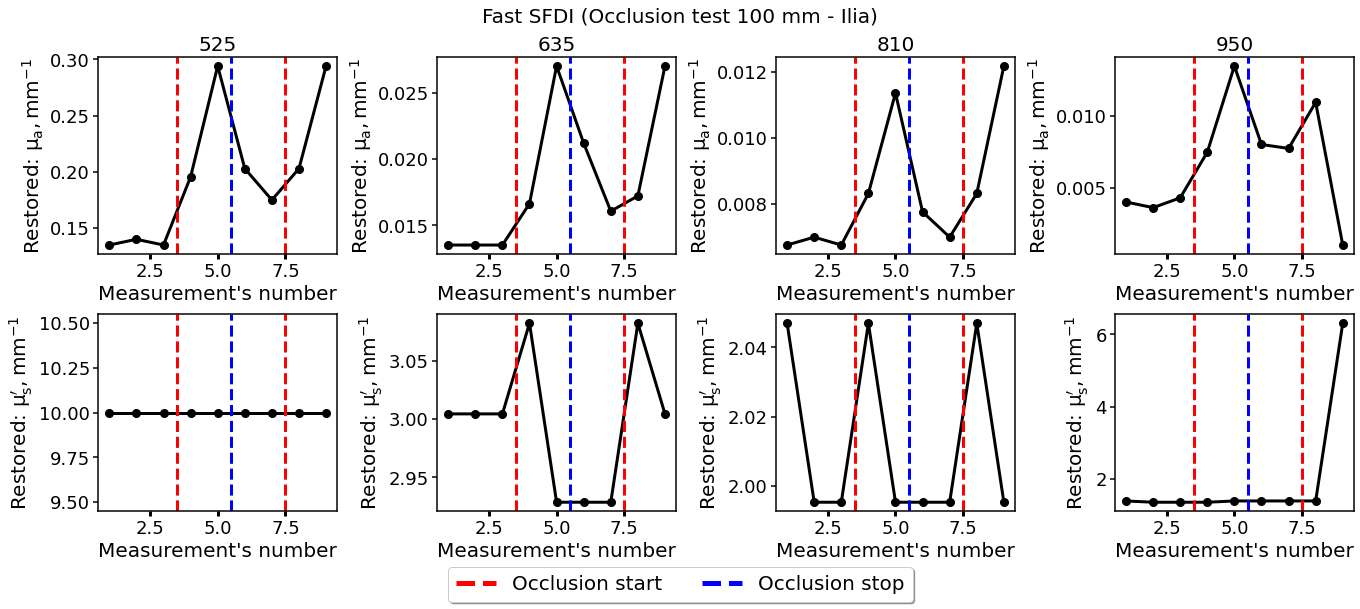

In [157]:
from matplotlib.lines import Line2D

par_to_plot = 'median'
fig, axes = plt.subplots(2, 4, figsize=(19,8))
fig.suptitle('Fast SFDI (Occlusion test 100 mm - Ilia)', fontsize=20)

for i, wv in enumerate(['525', '635', '810', '950']):
    
    _df_ssmd = df.copy()
    
    ax1 = axes[0, i]
    ax1.plot(_df_ssmd[f'number'], _df_ssmd[f'mua_{wv}_{par_to_plot}'], 'o-', c='black')
    
    ax1.set_title(wv)
    ax1.set_ylabel(r"Restored: $\rm \mu_a, mm^{-1}$")
    ax1.set_xlabel(r"Measurement's number")
    ax1.axvline(3.5, linestyle='dashed', c='r', label='Occlusion start' if i == 0 else "")
    ax1.axvline(5.5, linestyle='dashed', c='b', label='Occlusion stop' if i == 0 else "")
    ax1.axvline(7.5, linestyle='dashed', c='r')

    ax2 = axes[1, i]
    ax2.plot(_df_ssmd[f'number'], _df_ssmd[f'mus_{wv}_{par_to_plot}'], 'o-', c='black')
 
    ax2.set_ylabel(r"Restored: $\rm \mu_s', mm^{-1}$")
    ax2.set_xlabel(r"Measurement's number")
    ax2.axvline(3.5, linestyle='dashed', c='r')
    ax2.axvline(5.5, linestyle='dashed', c='b')
    ax2.axvline(7.5, linestyle='dashed', c='r')

# Create custom legend handles with larger font
legend_elements = [Line2D([0], [0], color='r', linestyle='dashed', linewidth=5, label='Occlusion start'),
                   Line2D([0], [0], color='b', linestyle='dashed', linewidth=5, label='Occlusion stop')]

# Adjust layout - first tight_layout, then add space for legend
plt.tight_layout()

fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
        fontsize=20, frameon=True, fancybox=True, shadow=True,
           bbox_to_anchor=(0.5, -0.07))  # Adjust position relative to figure

plt.show()

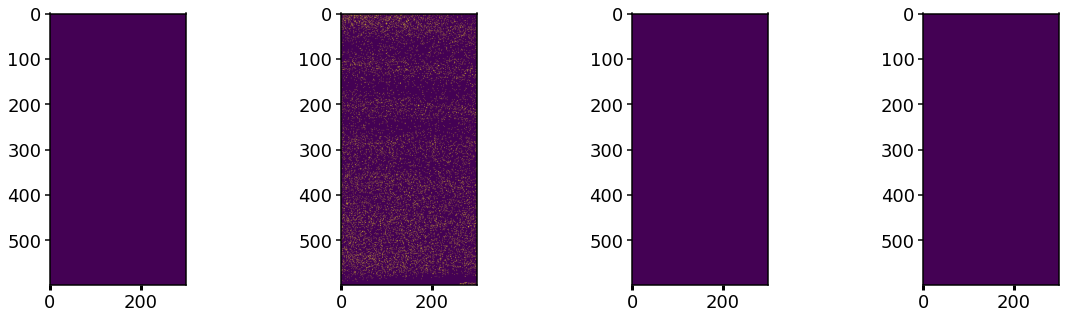

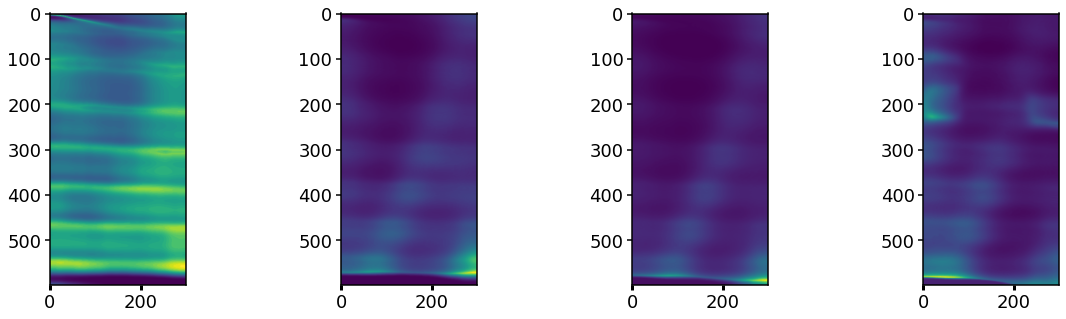

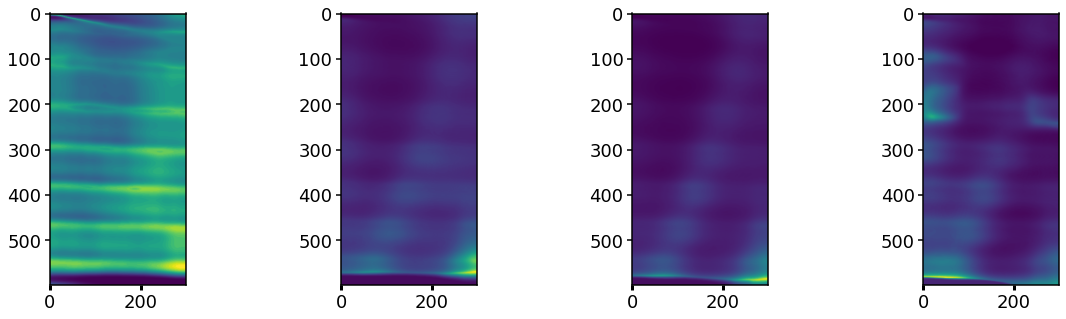

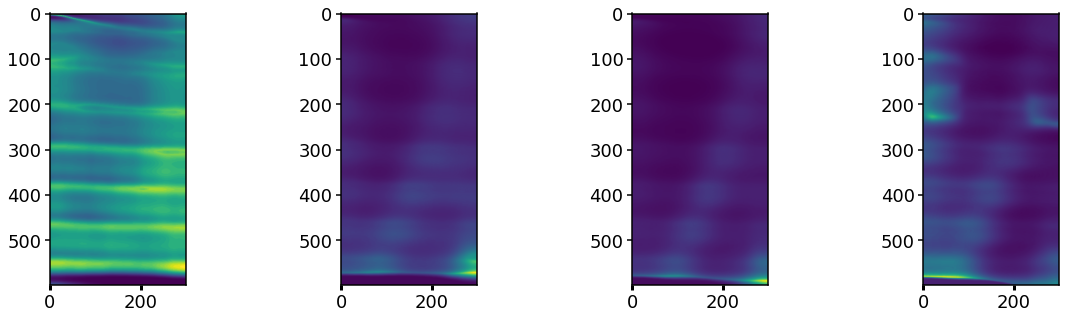

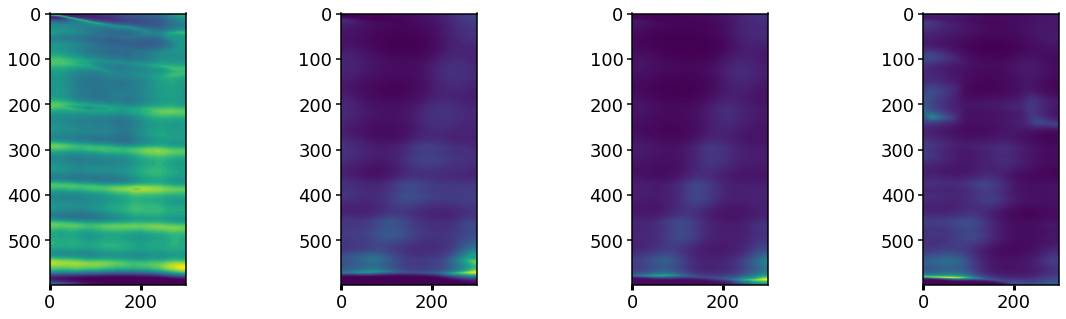

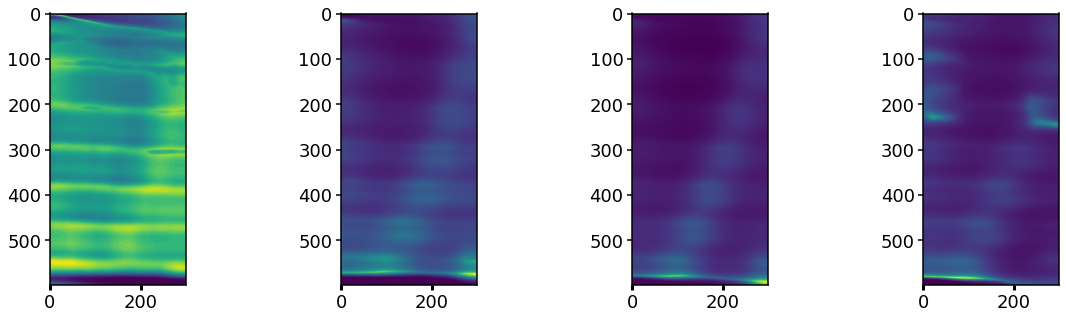

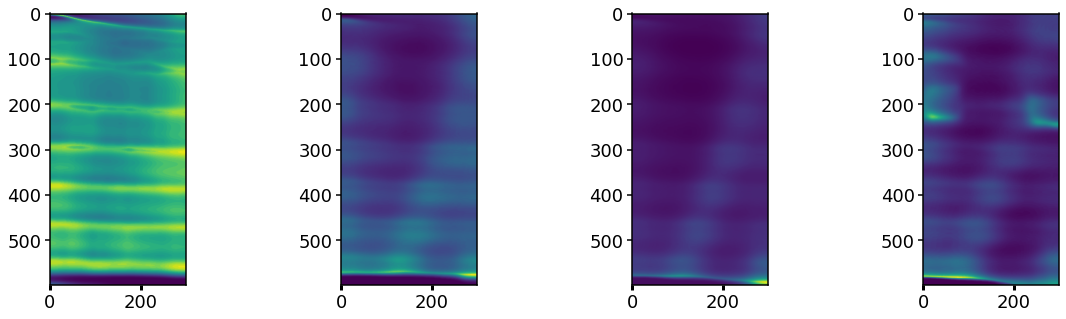

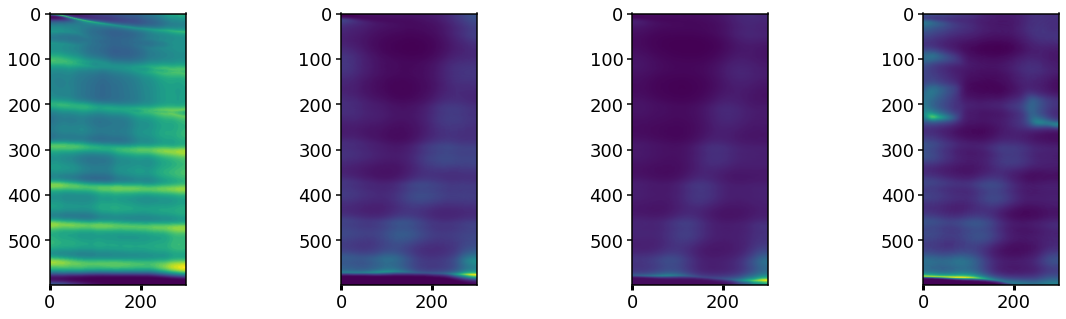

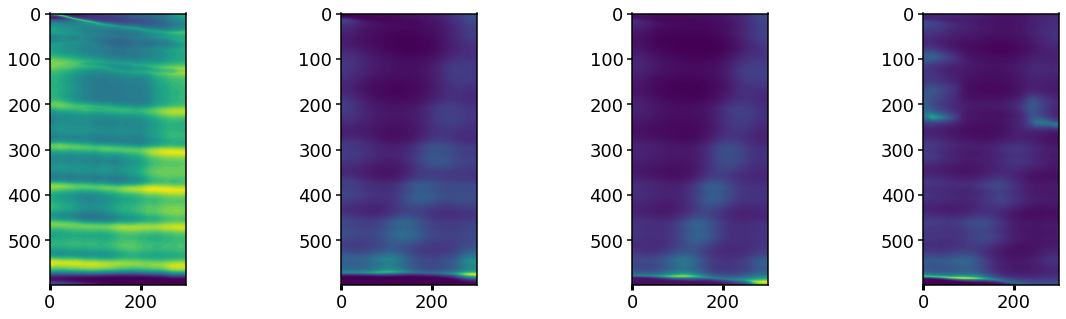

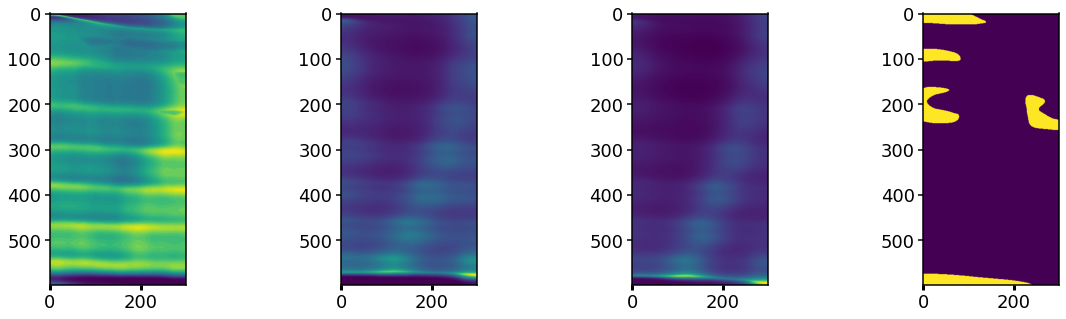

In [153]:

for _, row in data_ssmd.iterrows():
    
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(row['mua_525'].T)
    
    plt.subplot(1, 4, 2)
    plt.imshow(row['mua_635'].T)
    
    plt.subplot(1, 4, 3)
    plt.imshow(row['mua_810'].T)
    
    plt.subplot(1, 4, 4)
    plt.imshow(row['mua_950'].T)
    
    plt.show()